# Machine Learning Project - Data Visualization
## Library imports

In [238]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RANSACRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet

## Data Importation 

In [239]:
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_test = np.load('X_test.npy')

## DataFrame Creation

It will be easier for data visualization to work with pandas dataframes

In [240]:
# Features's Names
column_names_X = ['air_tmp','water_tmp','wind_speed','wind_dir','illumination']
column_names_y = ['toxic_concentration']
column_names_X_test = ['air_tmp','water_tmp','wind_speed','wind_dir','illumination']

# Creating DataFrames
df_X_train = pd.DataFrame(X_train)
df_y_train = pd.DataFrame(y_train)
df_X_test = pd.DataFrame(X_test)

# Attributing Column Names
df_X_train.columns = column_names_X
df_y_train.columns = column_names_y
df_X_test.columns = column_names_X_test

# Data Visualization

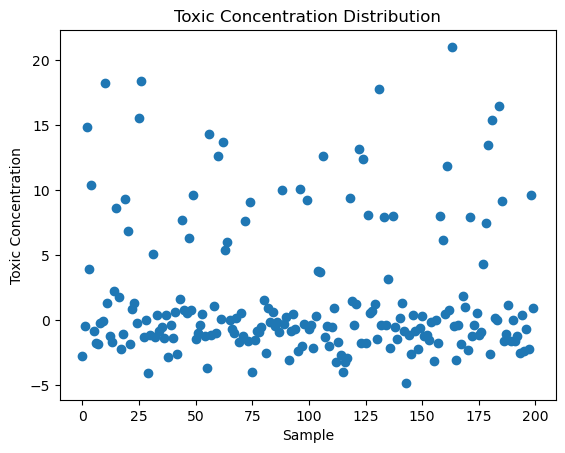

In [241]:
plt.scatter(range(0,df_X_train.shape[0]), df_y_train['toxic_concentration'])
plt.title('Toxic Concentration Distribution')
plt.ylabel('Toxic Concentration')   
plt.xlabel('Sample')
plt.show()

## Correlation between features

We create a new data DataFrame for plotting the correlation heatmap:

In [242]:
df_train = df_X_train.copy()
df_train['toxic_concentration'] = df_y_train[:]
df_train.head(2)

,air_tmp,water_tmp,wind_speed,wind_dir,illumination,toxic_concentration
0,243.603602,320.129329,263.887099,138.347154,187.518604,-2.737384
1,0.807288,-0.036818,627.205787,149.999110,109.295966,-0.410969


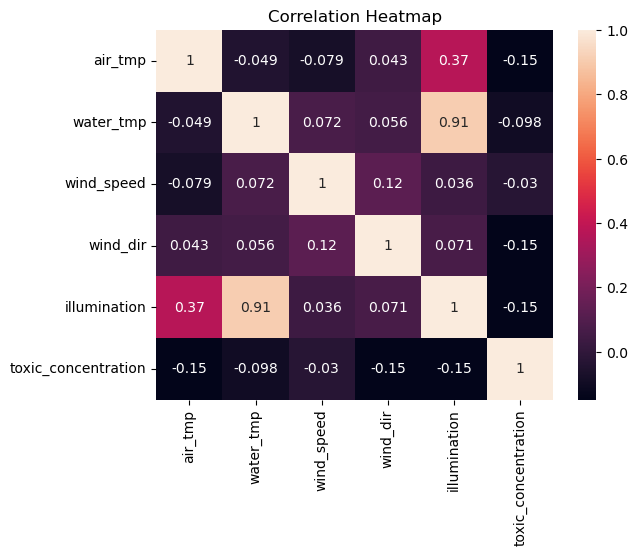

In [243]:
# Plotting correlation heatmap
dataplot = sb.heatmap(df_train.corr(numeric_only=True), annot=True)

# Displaying heatmap
plt.title("Correlation Heatmap")
plt.show()

We can observe a correlation between illumination and air temperature and between illumination and water temperature. The other pairs are not correlate exept for the wind direction and speed. 
$\newline$ Water and air temperatures increase when the illumination is higher.

# Machine Learning Project - Linear Regression

## Multiple Linear Regression - With Outliers

### First Model

In [244]:
# Let's start the linear regression
lm = LinearRegression()
model = lm.fit(X_train, y_train)
print(f"\t y = {model.intercept_:.4f} + {model.coef_[0]:.4f}x_1 + {model.coef_[1]:.4f}x_2 + {model.coef_[2]:.4f}x_3 + {model.coef_[3]:.4f}x_4 + {model.coef_[4]:.4f}x_5")

	 y = -33.0704 + -0.0211x_1 + -0.0891x_2 + -0.0006x_3 + -0.0355x_4 + 0.3774x_5


Our linear regression model is : $\newline$ 
$$y = \beta_0 + \beta_1x_{1} + \beta_2x_2 + \beta_3x_3 + \beta_4x_4 + \beta_5x_5$$

$$y = -33.0704 + -0.0211 \times x_{1} + -0.0891 \times x_2 + -0.0006 \times x_3 + -0.0355 \times x_4 + 0.3774 \times x_5$$

We can see that $\beta_3$ is very low so we could try to delete $x_3$ from our model to improve time computation while having the same acurracy.

### Interpretations

The only feature implied in higher toxicity is illumination. Greater the illumination is higher the toxicity is.

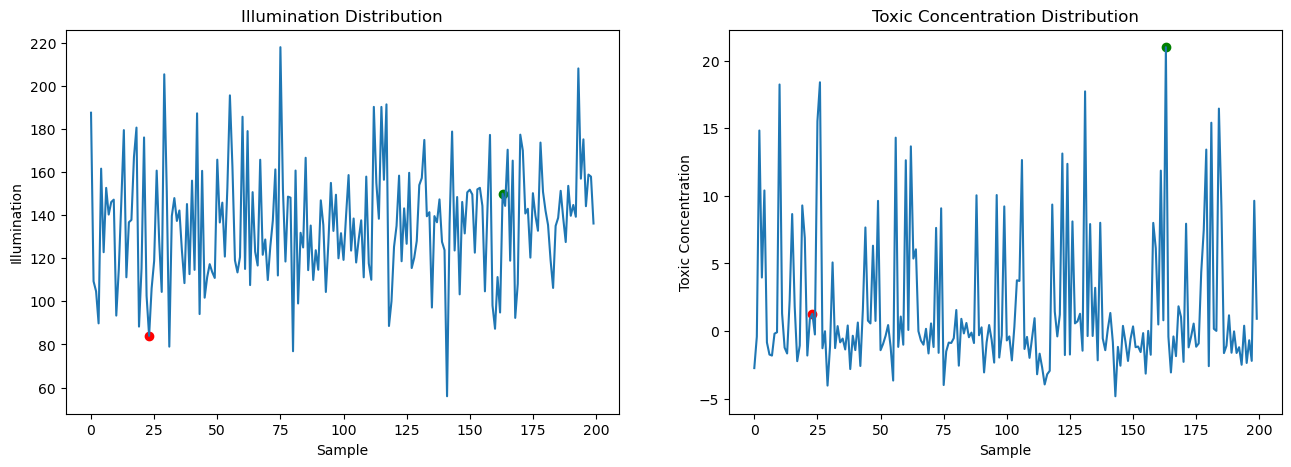

In [245]:
plt.subplot(1, 2, 1)
plt.plot(range(0,200),df_X_train["illumination"])
plt.title('Illumination Distribution')
plt.ylabel('Illumination')
plt.xlabel('Sample')
plt.scatter(23, df_X_train["illumination"][23], color='red',label = "small illumination sample")
plt.scatter(163,df_X_train["illumination"][163], color='green',label = "big illumination sample")

plt.subplot(1, 2, 2)
plt.plot(range(0,200),df_y_train["toxic_concentration"])
plt.title('Toxic Concentration Distribution')
plt.ylabel('Toxic Concentration')
plt.xlabel('Sample')
plt.scatter(23, df_y_train["toxic_concentration"][23], color='red',label = "small illumination sample")
plt.scatter(163,df_y_train["toxic_concentration"][163], color='green',label = "big illumination sample")
plt.subplots_adjust(left=0.1, right=2, top=0.9, bottom=0.1)

### Predictions

We are going to make the predicitons and compare them with the train set and square the result so that we will have the cuadratic loss  

25.020208183362055


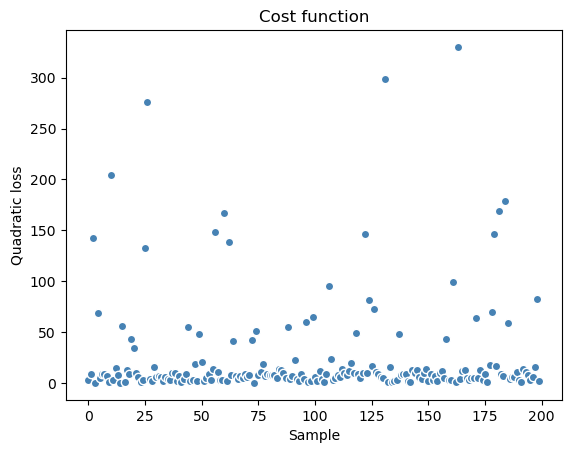

In [246]:
y_train_pred = model.predict(X_train)

quadratic_loss = (y_train_pred - y_train)**2

plt.scatter(range(0,200), quadratic_loss, c='steelblue', marker='o',
            edgecolor='white', label='Entrenamiento')

plt.title('Cost function')
plt.ylabel('Quadratic loss')
plt.xlabel('Sample')

print(quadratic_loss.mean())

### Score

In [247]:
print(mean_squared_error(y_train, y_train_pred))#SSE
print(r2_score(y_train, y_train_pred)) #coefficient of determination = 1-SSE/standard deviation 

25.020208183362055
0.060559944384204645


Our first approach of the model is not working very well. As we see in the cost plot, there are big errors in some samples. The coefficient of determination whose best value, 1, is achieved when SSE=0 (no erros), is too low.  Therefore, our goal is to remove those conflicting samples and to meassure the performance of the model again.

### RANSAC ALGORITHM

In [248]:
ransac = RANSACRegressor(LinearRegression(), max_trials=150, min_samples=None, #número mínimo de muestras a considerar típicas
                         loss='absolute_error', residual_threshold=6, #Método para calcular el error y el umbral para considerar una muestra como típica
                        )
ransac.fit(X_train, y_train)
#Nuevamente ransac espera una matriz, no un array, por tanto convertimos a matriz de una columna

RANSACRegressor(estimator=LinearRegression(), max_trials=150,
                residual_threshold=6)

/var/folders/qb/pq0sgc991zz91c7hqpvt3df00000gn/T/ipykernel_1807/936133004.py:13: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(atypic_sample_position, y_train[atypic_sample_mask],


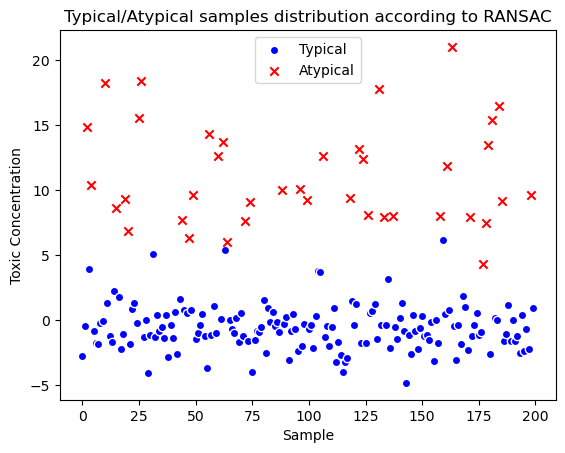

In [249]:
# We find the "atypical" samples 
typic_sample_mask = ransac.inlier_mask_ #Typical samples
atypic_sample_mask = np.logical_not(typic_sample_mask) #Atypical samples

# We locate those samples 
typic_sample_position = np.where(typic_sample_mask)[0]
atypic_sample_position = np.where(atypic_sample_mask)[0]


# We point to them
plt.scatter(typic_sample_position, y_train[typic_sample_mask],
            c='blue', edgecolor='white', marker='o', label='Typical')
plt.scatter(atypic_sample_position, y_train[atypic_sample_mask],
            c='red', edgecolor='white', marker='x', label='Atypical')

plt.title('Typical/Atypical samples distribution according to RANSAC')
plt.ylabel('Toxic Concentration')   
plt.xlabel('Sample')
plt.legend(loc="upper center")

Now, we have found those conflicting samples, we are going to remove them from the training set and meassure the model performance. 

In [250]:
y_train_pred = ransac.predict(X_train[typic_sample_position,:])

39


In [251]:
print(f"\t y = {ransac.estimator_.intercept_:.4f} + {ransac.estimator_.coef_[0]:.4f}x_1 + {ransac.estimator_.coef_[1]:.4f}x_2 + {ransac.estimator_.coef_[2]:.4f}x_3 + {ransac.estimator_.coef_[3]:.4f}x_4 + {ransac.estimator_.coef_[4]:.4f}x_5")

	 y = 1.2783 + -0.0053x_1 + -0.0085x_2 + -0.0006x_3 + -0.0047x_4 + 0.0037x_5


Our linear regression model without outliers is : $\newline$ 
$$y = \beta_0 + \beta_1x_{1} + \beta_2x_2 + \beta_3x_3 + \beta_4x_4 + \beta_5x_5$$

$$y = 1.2783 - 0.0053 \times x_{1} - 0.0085 \times x_2 - 0.0006 \times x_3 - 0.0047 \times x_4 + 0.0037 \times x_5$$

0.7955966274845467


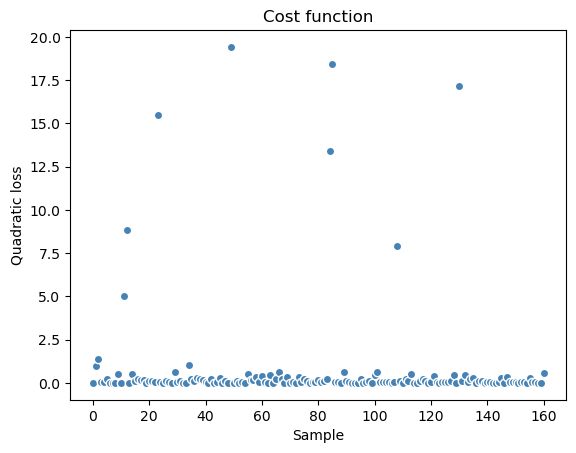

In [252]:
quadratic_loss = (y_train_pred - y_train[typic_sample_position])**2

plt.scatter(range(0,quadratic_loss.shape[0]), quadratic_loss, c='steelblue', marker='o',
            edgecolor='white', label='Entrenamiento')

plt.title('Cost function')
plt.ylabel('Quadratic loss')
plt.xlabel('Sample')

print(quadratic_loss.mean())

### Score

In [253]:
print(mean_squared_error(y_train[typic_sample_position], y_train_pred))
print(r2_score(y_train[typic_sample_position], y_train_pred))

0.7955966274845467
0.7290414193648803


We realize that the performance parameters have improved significantly. Even so, we want to try to make it work in a better way, we are going to try to go beyond. 

### Data pre-processing 

In [254]:
X_train_processed = X_train.copy()
y_train_processed = y_train.copy()
'''
for i in range(X_train_processed.shape[1]):
    X_train_processed[:,i] = (X_train_processed[:,i]-np.mean(X_train_processed[:,i]))

y_train_processed[:] = (y_train_processed[:]-np.mean(y_train_processed[:]))'''

'\nfor i in range(X_train_processed.shape[1]):\n    X_train_processed[:,i] = (X_train_processed[:,i]-np.mean(X_train_processed[:,i]))\n\ny_train_processed[:] = (y_train_processed[:]-np.mean(y_train_processed[:]))'

Let's try with Lasso regularization:

In [260]:
# Model creation
L1 = Lasso(alpha=0.05)

# Model training
L1.fit(X_train_processed[typic_sample_position], y_train_processed[typic_sample_position])

# Prediction ingoring atypical samples
y_ent_pred = L1.predict(X_train_processed[typic_sample_position])

print('Performance = ',r2_score(y_train_processed[typic_sample_position], y_ent_pred))
print('Number of features before regularization = %d ' % (X_train_processed.shape[1]))
print('Number of features after regularization = %d ' % (np.count_nonzero(L1.coef_)))
print(L1.coef_)

Performance =  0.7290312563399427
Number of features before regularization = 5 
Number of features after regularization = 4 
[-0.00515874 -0.00770745 -0.00062913 -0.00455993 -0.        ]


Let's try with Ridge regularization:

In [256]:
# Model creation
L2 = Ridge(alpha=1)

# Model training
L2.fit(X_train_processed[typic_sample_position], y_train_processed[typic_sample_position])

# Prediction ingoring atypical samples
y_ent_pred = L2.predict(X_train_processed[typic_sample_position])

print('Performance = ',r2_score(y_train_processed[typic_sample_position], y_ent_pred))
print('Number of features before regularization = %d ' % (X_train_processed.shape[1]))
print('Number of features after regularization = %d ' % (np.count_nonzero(L2.coef_)))
print(L2.coef_)

Performance =  0.7290414190996006
Number of features before regularization = 5 
Number of features after regularization = 5 
[-0.00533077 -0.00852616 -0.00062981 -0.00470549  0.00364174]


In [257]:
# Model creation
elastNet = ElasticNet(alpha=0.21, l1_ratio=0.3) #alpha controla el grado de regularización

# Model training
elastNet.fit(X_train_processed[typic_sample_position], y_train_processed[typic_sample_position])

# Prediction ingoring atypical samples
y_ent_pred = elastNet.predict(X_train_processed[typic_sample_position])

print('Performance = ',r2_score(y_train_processed[typic_sample_position], y_ent_pred))
print('Number of features before regularization = %d ' % (X_train_processed.shape[1]))
print('Number of features after regularization = %d ' % (np.count_nonzero(elastNet.coef_)))


Performance =  0.7290297006001423
Number of features before regularization = 5 
Number of features after regularization = 4 


We decided to only use Lasso regularization becuase Ridge is intended to be used with great datsatsets with big correlations between features. 